# 01 — Single-Point Historical VaR

**Lesson:** What historical VaR actually computes, and how confidence level and interpolation method affect the result.

This notebook answers: *given a position and a history of returns, what's the worst loss we'd expect on a typical day?*

## ⚙️ Parameters

Change these and re-run all cells to see the effect.

In [1]:
# ⚙️ Parameters
TICKER = "SPY"
START_DATE = "2020-01-01"
END_DATE = "2026-07-11"
CONFIDENCE = 0.95
METHOD = "interpolation"       # "interpolation" or "nearest-rank"
POSITION_VALUE = 1_000_000    # £ — set to None for percentage VaR

In [2]:
import sys
sys.path.insert(0, "..")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from src.historical_var import historical_var
from yfinance_helpers import download_close_prices, prepare_returns

%matplotlib inline
plt.rcParams["figure.facecolor"] = "white"

---

## Part A: Hand-worked example

Before we touch real data, let's understand what the function does with a tiny sample we can compute by hand.

### The sample

Ten returns, sorted from worst to best:

In [3]:
sample = [-0.05, -0.03, -0.02, -0.01, 0.00, 0.01, 0.02, 0.03, 0.04, 0.05]
n = len(sample)

print(f"n = {n}")
print(f"Sorted returns: {[f'{r:.0%}' for r in sample]}")

n = 10
Sorted returns: ['-5%', '-3%', '-2%', '-1%', '0%', '1%', '2%', '3%', '4%', '5%']


### The key mental move

For 95% confidence, we want the **5th percentile** — the return threshold that only 5% of days are worse than. That means we look at the left tail:

$$\text{Quantile}(r,\, 1-c) = \text{Quantile}(r,\, 0.05)$$

Then we negate it to report VaR as a positive loss:

$$\text{VaR}_{95\%} = -\text{Quantile}(r,\, 0.05)$$

### Linear interpolation (production standard)

The fractional index for the 5th percentile of 10 observations:

$$i = P \times (n - 1) = 0.05 \times 9 = 0.45$$

This means: 45% of the way from the worst return (−5%) to the second-worst (−3%):

$$\text{Quantile}_{0.05} = -5\% + 0.45 \times (-3\% - (-5\%)) = -5\% + 0.9\% = -4.1\%$$

$$\text{VaR}_{95\%} = -(-4.1\%) = 4.1\%$$

In [4]:
var_95 = historical_var(sample, confidence=0.95, method="interpolation")
var_99 = historical_var(sample, confidence=0.99, method="interpolation")
var_95_nr = historical_var(sample, confidence=0.95, method="nearest-rank")

print(f"95% VaR (interpolation): {var_95:.1%}")
print(f"99% VaR (interpolation): {var_99:.2%}")
print(f"95% VaR (nearest-rank):  {var_95_nr:.1%}")

95% VaR (interpolation): 4.1%
99% VaR (interpolation): 4.82%
95% VaR (nearest-rank):  5.0%


### Visual: where the quantile lands

The vertical line shows the 5th percentile under linear interpolation — between the two worst returns.

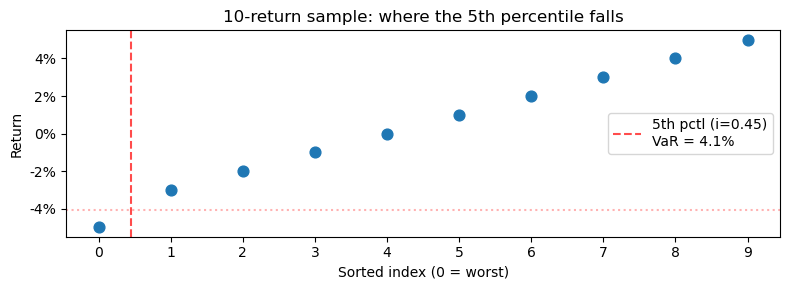

In [5]:
fig, ax = plt.subplots(figsize=(8, 3))
x = np.arange(n)
ax.scatter(x, sample, s=60, zorder=3)
ax.axvline(0.45, color="red", linestyle="--", alpha=0.7, label=f"5th pctl (i=0.45)\nVaR = {var_95:.1%}")
ax.axhline(-var_95, color="red", linestyle=":", alpha=0.3)
ax.set_xticks(x)
ax.set_xlabel("Sorted index (0 = worst)")
ax.set_ylabel("Return")
ax.set_title("10-return sample: where the 5th percentile falls")
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'{y:.0%}'))
ax.legend()
plt.tight_layout()
plt.show()

### Interpolation vs nearest-rank

With only 10 observations the difference is noticeable. With 252, it's a fraction of one day's return.

In [6]:
methods = ["interpolation", "nearest-rank"]
for method in methods:
    for conf in [0.90, 0.95, 0.99]:
        var = historical_var(sample, confidence=conf, method=method)
        print(f"{method:>14}  {conf:.0%} confidence  →  VaR = {var:.2%}")
    print()

 interpolation  90% confidence  →  VaR = 3.20%
 interpolation  95% confidence  →  VaR = 4.10%
 interpolation  99% confidence  →  VaR = 4.82%

  nearest-rank  90% confidence  →  VaR = 5.00%
  nearest-rank  95% confidence  →  VaR = 5.00%
  nearest-rank  99% confidence  →  VaR = 5.00%



---

## Part B: Real SPY data

Now the same calculation on real market returns.

In [7]:
prices = download_close_prices(TICKER, start=START_DATE, end=END_DATE)
returns = prepare_returns(prices)

print(f"Asset: {TICKER}")
print(f"Period: {returns.index[0].date()} → {returns.index[-1].date()}")
print(f"Observations: {len(returns)}")
print(f"Mean daily return: {returns.mean():.4%}")
print(f"Std daily return:  {returns.std():.4%}")
print(f"Worst day: {returns.min():.4%}")
print(f"Best day:  {returns.max():.4%}")

Prepared 1637 daily returns (2020-01-03 to 2026-07-10) from 1638 price observations.
Asset: SPY
Period: 2020-01-03 → 2026-07-10
Observations: 1637
Mean daily return: 0.0654%
Std daily return:  1.2781%
Worst day: -10.9424%
Best day:  10.5019%


### The return distribution

Historical VaR works directly on this shape — no assumptions about normality.

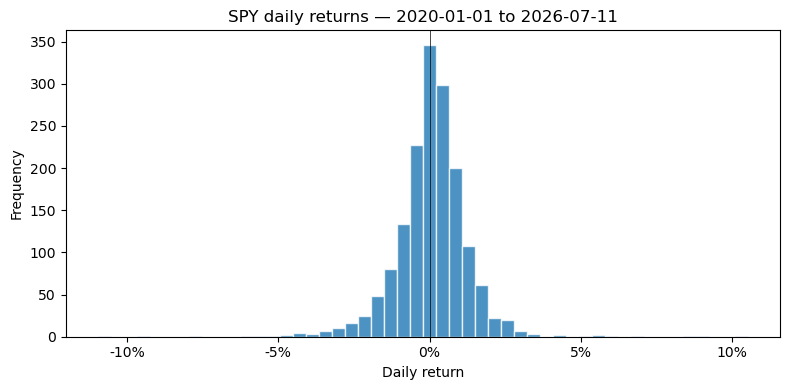

In [8]:
fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(returns, bins=50, edgecolor="white", alpha=0.8)
ax.axvline(0, color="black", linewidth=0.5)
ax.set_xlabel("Daily return")
ax.set_ylabel("Frequency")
ax.set_title(f"{TICKER} daily returns — {START_DATE} to {END_DATE}")
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:.0%}'))
plt.tight_layout()
plt.show()

### VaR at different confidence levels

Using the most recent 252 trading days (≈1 year).

In [9]:
recent = returns.iloc[-252:]

for conf in [0.90, 0.95, 0.99]:
    var_pct = historical_var(recent, confidence=conf, method=METHOD)
    var_gbp = historical_var(recent, confidence=conf, method=METHOD, position_value=POSITION_VALUE)
    print(f"{conf:.0%} VaR ({METHOD}): {var_pct:.2%}  →  £{POSITION_VALUE:,.0f} position = £{var_gbp:,.0f}")

90% VaR (interpolation): 0.88%  →  £1,000,000 position = £8,778
95% VaR (interpolation): 1.41%  →  £1,000,000 position = £14,126
99% VaR (interpolation): 1.91%  →  £1,000,000 position = £19,083


### Interpolation vs nearest-rank on real data

With 252 observations, the difference is barely visible.

In [10]:
var_interp = historical_var(recent, confidence=CONFIDENCE, method="interpolation")
var_nr = historical_var(recent, confidence=CONFIDENCE, method="nearest-rank")

print(f"{CONFIDENCE:.0%} VaR, 252-day window:")
print(f"  Interpolation: {var_interp:.4%}")
print(f"  Nearest-rank:  {var_nr:.4%}")
print(f"  Difference:     {abs(var_interp - var_nr):.4%}  ← {abs(var_interp - var_nr) / var_interp * 100:.1f}% of the estimate")

95% VaR, 252-day window:
  Interpolation: 1.4126%
  Nearest-rank:  1.4336%
  Difference:     0.0210%  ← 1.5% of the estimate


---

## Key insight

Historical VaR is mechanically simple — sort returns, pick a percentile, negate it. The method choice (interpolation vs nearest-rank) matters at tiny sample sizes but is a footnote at 252+ observations. **What actually matters is the sample: which returns are in the window and whether they represent tomorrow's risk.**

Next: [02 — Rolling VaR Backtest](./02_rolling_var_backtest.ipynb) — does this model actually work over time?